#1- CLASIFICACIÓN CON NAIVE BAYES

### 1-Importar los datos


In [ ]:
import pandas as pd
from google.colab import drive
drive.mount("/content/drive")

## Defino la raiz del sistema de archivos
#raiz="/content/dirve/MyDrive"

##Importo el archivo
solicitantes= pd.read_excel("/content/drive/MyDrive/Colab Notebooks/0. SolicitantesCrédito.xlsx")

Mounted at /content/drive


In [ ]:
solicitantes

,Unnamed: 0,Edad,Sexo,Estado civil,Hijos,Perscargo,Estrato,Nivel de estudios,Tipo de contrato,Ingresos,...,Plazo,Cuota (COP),ConoCliente,Garantia,RespPat,MoraCome,PreApr,Prob.Default (PD),Score,LGD
0,1,38,NR,Casado,1,0,3,Bachiller,Ninguno,5424576,...,48,82691.506204,Buenas Referencias,Sin Codeudor,Sin Patrimonio,Con Experiencia sin Mora,1.0,0.041659,582.478943,0.063702
1,2,51,NR,Separado,6,1,4,Técnico,Ninguno,1144064,...,36,22781.212598,Buenas Referencias,Sin Codeudor,Prop.sin Hipoteca,Con Experiencia sin Mora,1.0,0.234951,479.839966,0.465636
2,3,37,Mujer,Casado,2,0,3,Tecnólogo,Indefinido,2069853,...,36,46294.596244,Buenas Referencias,Con Codeudor(es),Sin Patrimonio,Con Experiencia sin Mora,0.0,0.170330,417.653107,0.290071
3,4,29,NR,Separado,1,0,2,Tecnólogo,Ninguno,1893080,...,24,69564.950015,Buenas Referencias,Con Codeudor(es),Sin Patrimonio,Con Experiencia sin Mora,1.0,0.201659,316.791107,0.278389
4,5,42,Mujer,Casado,3,4,2,Especializacion,Ninguno,3000367,...,24,112478.307883,Buenas Referencias,Con Codeudor(es),Sin Patrimonio,Con Experiencia sin Mora,1.0,0.140929,441.809570,0.203359
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8373,8374,31,Hombre,Soltero,2,0,5,Bachiller,Indefinido,5891088,...,48,115108.056436,Buena Experiencia CFB,Sin Codeudor,Sin Patrimonio,Con Experiencia sin Mora,1.0,0.035120,659.471375,0.066962
8374,8375,38,Hombre,Separado,0,0,3,Bachiller,Labor Contratada,3092079,...,36,96789.562091,Buenas Referencias,Sin Codeudor,Prop.sin Hipoteca,Con Experiencia sin Mora,1.0,0.101976,465.011536,0.165936
8375,8376,43,Mujer,Casado,1,2,2,Tecnólogo,Ninguno,2542007,...,36,49713.608249,Buenas Referencias,Sin Codeudor,Sin Patrimonio,Con Experiencia sin Mora,1.0,0.156707,423.237305,0.247763
8376,8377,37,Mujer,Casado,1,2,3,Tecnólogo,Indefinido,5677067,...,36,163602.818587,Buenas Referencias,Con Codeudor(es),Sin Patrimonio,Con Experiencia sin Mora,1.0,0.037719,592.670837,0.051356


In [ ]:
solicitantes.head(10)



,Unnamed: 0,Edad,Sexo,Estado civil,Hijos,Perscargo,Estrato,Nivel de estudios,Tipo de contrato,Ingresos,...,Plazo,Cuota (COP),ConoCliente,Garantia,RespPat,MoraCome,PreApr,Prob.Default (PD),Score,LGD
0,1,38,NR,Casado,1,0,3,Bachiller,Ninguno,5424576,...,48,82691.506204,Buenas Referencias,Sin Codeudor,Sin Patrimonio,Con Experiencia sin Mora,1.0,0.041659,582.478943,0.063702
1,2,51,NR,Separado,6,1,4,Técnico,Ninguno,1144064,...,36,22781.212598,Buenas Referencias,Sin Codeudor,Prop.sin Hipoteca,Con Experiencia sin Mora,1.0,0.234951,479.839966,0.465636
2,3,37,Mujer,Casado,2,0,3,Tecnólogo,Indefinido,2069853,...,36,46294.596244,Buenas Referencias,Con Codeudor(es),Sin Patrimonio,Con Experiencia sin Mora,0.0,0.170330,417.653107,0.290071
3,4,29,NR,Separado,1,0,2,Tecnólogo,Ninguno,1893080,...,24,69564.950015,Buenas Referencias,Con Codeudor(es),Sin Patrimonio,Con Experiencia sin Mora,1.0,0.201659,316.791107,0.278389
4,5,42,Mujer,Casado,3,4,2,Especializacion,Ninguno,3000367,...,24,112478.307883,Buenas Referencias,Con Codeudor(es),Sin Patrimonio,Con Experiencia sin Mora,1.0,0.140929,441.809570,0.203359
5,6,50,Mujer,Casado,1,1,2,Primaria,Labor Contratada,1957244,...,36,52644.131911,Buena Experiencia CFB,Sin Codeudor,Inversiones,Con Experiencia sin Mora,1.0,0.179816,418.180756,0.297978
6,7,38,NR,Soltero,3,0,3,Profesional,Indefinido,1534711,...,60,20094.138009,Buenas Referencias,Sin Codeudor,Sin Patrimonio,Con Experiencia sin Mora,NaN,NaN,NaN,NaN
7,8,47,Mujer,Casado,0,0,2,Profesional,Ninguno,136750,...,48,3563.229109,Buena Experiencia CFB,Sin Codeudor,Sin Patrimonio,Con Experiencia sin Mora,NaN,NaN,NaN,NaN
8,9,29,NR,Soltero,2,0,2,Bachiller,Indefinido,1114320,...,18,68437.780632,Buenas Referencias,Libranza Establecida,Sin Patrimonio,Con Experiencia sin Mora,0.0,0.276393,273.556274,0.379541
9,10,42,Hombre,Separado,0,0,5,Técnico,Indefinido,2177515,...,36,81787.391384,Buena Experiencia CFB,Sin Codeudor,Sin Patrimonio,Con Experiencia sin Mora,0.0,0.120541,509.921600,0.259496


In [ ]:
solicitantes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8378 entries, 0 to 8377
Data columns (total 35 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               8378 non-null   int64  
 1   Edad                     8378 non-null   int64  
 2   Sexo                     8378 non-null   object 
 3   Estado civil             8378 non-null   object 
 4   Hijos                    8378 non-null   int64  
 5   Perscargo                8378 non-null   int64  
 6   Estrato                  8378 non-null   int64  
 7   Nivel de estudios        8378 non-null   object 
 8   Tipo de contrato         8378 non-null   object 
 9   Ingresos                 8378 non-null   int64  
 10  Egresos                  8378 non-null   int64  
 11  Tipo de actividad        8378 non-null   object 
 12  Tipo de vivienda         8378 non-null   object 
 13  Total Activos            8378 non-null   float64
 14  Total pasivos           

### 2-Limpieza de los datos


In [ ]:
solicitantes.shape

(8378, 35)

In [ ]:
## Elimino las filas donde "PreApr" está vacío

XD=solicitantes.dropna(subset=["PreApr"])

In [ ]:
XD.shape

(5842, 35)

In [ ]:
# Seleccionamos solo las variables independientes del modelo
XD=XD[["Edad","Ingresos","Egresos","Monto (EAD)","Hijos","Perscargo","Estrato","Plazo","Cuota (COP)"]]

In [ ]:
## Escojo la variable dependiente del modelo
yd=solicitantes["PreApr"].dropna()   #con un solo corchete para convertirlo facil a arreglo

### 3- implementación del modelo Naive Bayes


In [ ]:
## Importo las librerias necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.naive_bayes import GaussianNB


In [ ]:
# Conviertop los datasets a arrays
XDArray = np.array(XD,dtype=float)
ydArray = np.array(yd, dtype=float)

In [ ]:
# Entrenar el modelo de naive Bayes
modelNB = GaussianNB()
modelNB.fit(XDArray, ydArray)

GaussianNB()

In [ ]:
## Predice los yd
ydPred=modelNB.predict(XDArray)
ydPred

array([1., 0., 0., ..., 0., 0., 1.])

### 4.Matriz de Confusión

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm=confusion_matrix(ydArray, ydPred)
cm

array([[2539,  420],
       [1041, 1842]])

In [ ]:
cm[1][1]

1842

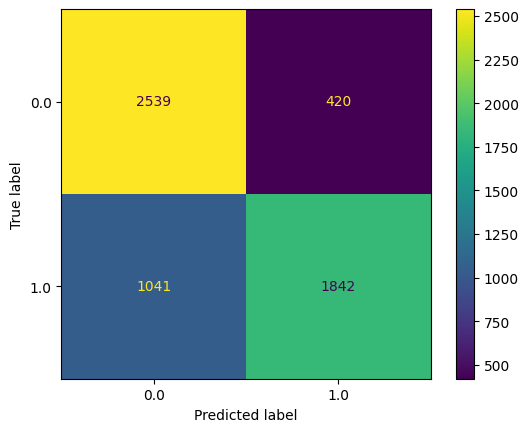

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelNB.classes_)
disp.plot()
plt.show()

### 5.Metricas de exatitud de modelo

In [ ]:
## Exactitud (Accuracy)
## Numero de predicciones correctas sobre el total de predicciones
exactitud = (cm[1][1] + cm[0][0])/cm.sum()
print(f"la exactitud (accuracy) del modelo es de {exactitud:.2%}")

la exactitud (accuracy) del modelo es de 74.99%


## Este resultado demuestra que al darse un aumento de 9 variables en el modelo, su precisión en cuanto bajó de 76.14% a 74.99%

In [ ]:
## Tasa de error
## Numero de predicciones incorrectas sobre el total de predicciones

##Opcion 1
error = (cm[1][0] + cm[0][1])/cm.sum()

##Opcion 2
error = 1 - exactitud

print(f"el error del modelo es de {error:.2%}")

el error del modelo es de 25.01%


# La tasa de error con 4 variables es de 23.86% y ahora, al agregarle 9 variables al modelo su número de predicciones incorrectas sobre el total de predicciones es de 25.01%, así que se evidencia un aumento gracias al incremento de variables  

In [ ]:
## Precisión
## que tan cerca está el resultado de un valor verdadero . De los que calcula como verdaderos
## Cuales son efectivamente verdaderos
precisión = cm[1][1]/(cm[1][1] + cm[0][1])
print(f"la precision del modelo es de {precisión:.2%}")

la precision del modelo es de 81.43%


# que tan cerca está el resultado de un valor verdadero . De los que calcula como verdaderos, por ejemplo con 4 variables es de 81.01%, aunque por otro lado, con 9 variables es de 81.43%, tiene una variación bastante mínima comparada con los demás análisis, y esto se puede dar por múltiples variables como lo es la distribución de los datos

In [ ]:
(cm[1][1] + cm[1][0])

2883

In [ ]:
## Sencibilidad (RECALL)
## Es la cantidad de positivos bien clasificados por el modelo
## Respecto al total de positivos.
sencibilidad = cm[1][1]/(cm[1][1] + cm[1][0])
print(f"la sencibilidad del modelos es de {sencibilidad:.2%}")

la sencibilidad del modelos es de 63.89%


# La sencibilidad del modelo también muestra una disminución que pasa de un 67.46% a un 63.89%, esto puede darse porque al aumentar de variables también incrementa la complejidad del modelo para identificar datos, o porque las variables ya existentes puedan otorgar información similar a las variables  ingresadas

In [ ]:
## Especificidad
## Es la cantidad de negativos bien clasificados por el modelo
## Respecto al total de negativos
especificidad = cm[0][0]/(cm[0][1] + cm[0][0])
print(f"la espeficidad del modelo es de {especificidad:.2%}")

la espeficidad del modelo es de 85.81%


# Podemos observar nuevamente un aumento en la especificidad de 84.59% a un 85.81%, aquí por ejemplo se puede reducir los falsos positivos

## 6. Pronóstico de PreAp para solicitantes nuevos

In [ ]:
## Filtro solicitantes que no tienen valor en PreApr

XDGener = solicitantes[solicitantes["PreApr"].isna()]
XDGener

,Unnamed: 0,Edad,Sexo,Estado civil,Hijos,Perscargo,Estrato,Nivel de estudios,Tipo de contrato,Ingresos,...,Plazo,Cuota (COP),ConoCliente,Garantia,RespPat,MoraCome,PreApr,Prob.Default (PD),Score,LGD
6,7,38,NR,Soltero,3,0,3,Profesional,Indefinido,1534711,...,60,2.009414e+04,Buenas Referencias,Sin Codeudor,Sin Patrimonio,Con Experiencia sin Mora,NaN,NaN,NaN,NaN
7,8,47,Mujer,Casado,0,0,2,Profesional,Ninguno,136750,...,48,3.563229e+03,Buena Experiencia CFB,Sin Codeudor,Sin Patrimonio,Con Experiencia sin Mora,NaN,NaN,NaN,NaN
11,12,46,Mujer,Casado,0,1,4,Primaria,Indefinido,7097220,...,3,1.090054e+06,Buenas Referencias,Con Codeudor(es),Prop.sin Hipoteca,Con Experiencia sin Mora,NaN,NaN,NaN,NaN
13,14,37,Mujer,Soltero,4,2,2,Técnico,Ninguno,1791987,...,48,6.856249e+04,Buena Experiencia CFB,Sin Codeudor,Prop.sin Hipoteca,Mora mayor a 60 Dìas,NaN,NaN,NaN,NaN
16,17,22,NR,Unión Libre,1,0,2,Bachiller,Fijo,2892545,...,36,6.824255e+04,Buenas Referencias,Sin Codeudor,Sin Patrimonio,Con Experiencia sin Mora,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8357,8358,24,NR,Casado,1,0,4,Técnico,Fijo,2433168,...,48,1.026380e+05,Buenas Referencias,Con Codeudor(es),Vehìculo sin Prenda,Sin experiencia,NaN,NaN,NaN,NaN
8358,8359,66,Hombre,Unión Libre,1,0,1,Técnico,Indefinido,83684,...,24,1.908509e+03,Buenas Referencias,Libranza Establecida,Sin Patrimonio,Mora mayor a 60 Dìas,NaN,NaN,NaN,NaN
8367,8368,32,NR,Unión Libre,0,1,4,Bachiller,Fijo,1133063,...,36,3.665316e+04,Buenas Referencias,Sin Codeudor,Sin Patrimonio,Con Experiencia sin Mora,NaN,NaN,NaN,NaN
8372,8373,35,Hombre,Separado,2,1,3,Primaria,Indefinido,3073152,...,18,1.375805e+05,Buenas Referencias,Con Codeudor(es),Sin Patrimonio,Con Experiencia sin Mora,NaN,NaN,NaN,NaN


In [ ]:
## Acotar la dimensionalidad del dataset

XDGener = XDGener[["Edad","Ingresos","Egresos","Monto (EAD)","Hijos","Perscargo","Estrato","Plazo","Cuota (COP)"]]
XDGener

,Edad,Ingresos,Egresos,Monto (EAD),Hijos,Perscargo,Estrato,Plazo,Cuota (COP)
6,38,1534711,1658694,7.913126e+05,3,0,3,60,2.009414e+04
7,47,136750,171155,1.213014e+05,0,0,2,48,3.563229e+03
11,46,7097220,9525257,3.174456e+06,0,1,4,3,1.090054e+06
13,37,1791987,1391431,2.334042e+06,4,2,2,48,6.856249e+04
16,22,2892545,3576891,1.887636e+06,1,0,2,36,6.824255e+04
...,...,...,...,...,...,...,...,...,...
8357,24,2433168,1518301,3.494059e+06,1,0,4,48,1.026380e+05
8358,66,83684,120852,3.822821e+04,1,0,1,24,1.908509e+03
8367,32,1133063,766199,1.013852e+06,0,1,4,36,3.665316e+04
8372,35,3073152,3812690,2.156239e+06,2,1,3,18,1.375805e+05


In [ ]:
## Convierto el dataframe a un array para poder ingresarlo al modelo de Naive Bayes

XDGener = np.array(XDGener,dtype=float)

In [ ]:
## Le solicito al modelo que me haga el pronóstico a los solicitantes que aún no han recibido evaluación

ydGener = modelNB.predict(XDGener)

In [ ]:
ydGenerserie = pd.Series(ydGener,index=solicitantes[solicitantes["PreApr"].isna()].index)

In [ ]:
solicitantes["PreApr"].fillna(ydGenerserie,inplace=True)

In [ ]:
solicitantes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8378 entries, 0 to 8377
Data columns (total 35 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               8378 non-null   int64  
 1   Edad                     8378 non-null   int64  
 2   Sexo                     8378 non-null   object 
 3   Estado civil             8378 non-null   object 
 4   Hijos                    8378 non-null   int64  
 5   Perscargo                8378 non-null   int64  
 6   Estrato                  8378 non-null   int64  
 7   Nivel de estudios        8378 non-null   object 
 8   Tipo de contrato         8378 non-null   object 
 9   Ingresos                 8378 non-null   int64  
 10  Egresos                  8378 non-null   int64  
 11  Tipo de actividad        8378 non-null   object 
 12  Tipo de vivienda         8378 non-null   object 
 13  Total Activos            8378 non-null   float64
 14  Total pasivos           

In [ ]:
## Exportamos a la carpeta content

solicitantes.to_excel("QuizOk.xlsx")

In [ ]:
## Si queremos exportar a Drive

solicitantes.to_excel("/content/drive/MyDrive/Colab Notebooks/QuizOk.xlsx")
